# Neural Network on Pima Indians Diabetes Dataset

## Overview
Applying the complete neural network pipeline to predict diabetes from clinical measurements.

**Dataset**: Pima Indians Diabetes (Kaggle)  
**Samples**: 768 patients  
**Features**: 8 clinical measurements  
**Classes**: Diabetes (0=No, 1=Yes)  
**Expected Accuracy**: 70–75%

> **Setup**: Place `diabetes.csv` (downloaded from Kaggle) in the same folder as this notebook before running.

In [17]:
# Set random seeds for reproducibility
import numpy as np
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('results', exist_ok=True)

print('✓ All libraries imported successfully!')

✓ All libraries imported successfully!


## 1. Load Pima Indians Diabetes Dataset

**Instructions**: Download `diabetes.csv` from Kaggle and place it in the same directory as this notebook (or upload it to Colab).

In [18]:
# --- COLAB USERS: uncomment the next 3 lines to upload the file ---
# from google.colab import files
# uploaded = files.upload()  # select diabetes.csv from your computer

# Load the locally downloaded Kaggle CSV
# The Kaggle version already has headers and uses 'Outcome' as the target column
print('Loading Pima Indians Diabetes dataset from local CSV...')
data = pd.read_csv('diabetes.csv')

# Kaggle column names (already in the CSV header)
feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                  'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
target_names = np.array(['No Diabetes', 'Diabetes'])

X = data[feature_names].values
y = data['Outcome'].values

print(f'Dataset loaded successfully!')
print(f'Total samples: {X.shape[0]}')
print(f'Total features: {X.shape[1]}')
print(f'Feature names: {feature_names}')
print(f'Target classes: {target_names}')
print(f'\nFirst 5 rows:')
print(data.head())

Loading Pima Indians Diabetes dataset from local CSV...
Dataset loaded successfully!
Total samples: 768
Total features: 8
Feature names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Target classes: ['No Diabetes' 'Diabetes']

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33      

## 2. Explore the Dataset

In [19]:
print('=' * 70)
print('PIMA INDIANS DIABETES DATASET EXPLORATION')
print('=' * 70)

print(f'\nTotal samples: {X.shape[0]}')
print(f'Total features: {X.shape[1]}')

print(f'\nFeatures represent clinical measurements:')
print(f'  • Number of pregnancies')
print(f'  • Plasma glucose concentration (2h oral glucose tolerance test)')
print(f'  • Diastolic blood pressure (mm Hg)')
print(f'  • Triceps skin fold thickness (mm)')
print(f'  • 2-Hour serum insulin (mu U/ml)')
print(f'  • Body mass index (weight in kg / height in m²)')
print(f'  • Diabetes pedigree function (genetic risk score)')
print(f'  • Age (years)')

print(f'\nClass Distribution:')
print(f'  No Diabetes (0): {np.sum(y == 0)} samples ({100*np.sum(y==0)/len(y):.1f}%)')
print(f'  Diabetes (1):    {np.sum(y == 1)} samples ({100*np.sum(y==1)/len(y):.1f}%)')

print(f'\nFeature Value Ranges:')
print(f'  Min values: {X.min(axis=0)}')
print(f'  Max values: {X.max(axis=0)}')
print(f'  Note: Features have very different scales → MUST normalize!')

PIMA INDIANS DIABETES DATASET EXPLORATION

Total samples: 768
Total features: 8

Features represent clinical measurements:
  • Number of pregnancies
  • Plasma glucose concentration (2h oral glucose tolerance test)
  • Diastolic blood pressure (mm Hg)
  • Triceps skin fold thickness (mm)
  • 2-Hour serum insulin (mu U/ml)
  • Body mass index (weight in kg / height in m²)
  • Diabetes pedigree function (genetic risk score)
  • Age (years)

Class Distribution:
  No Diabetes (0): 500 samples (65.1%)
  Diabetes (1):    268 samples (34.9%)

Feature Value Ranges:
  Min values: [ 0.     0.     0.     0.     0.     0.     0.078 21.   ]
  Max values: [ 17.   199.   122.    99.   846.    67.1    2.42  81.  ]
  Note: Features have very different scales → MUST normalize!


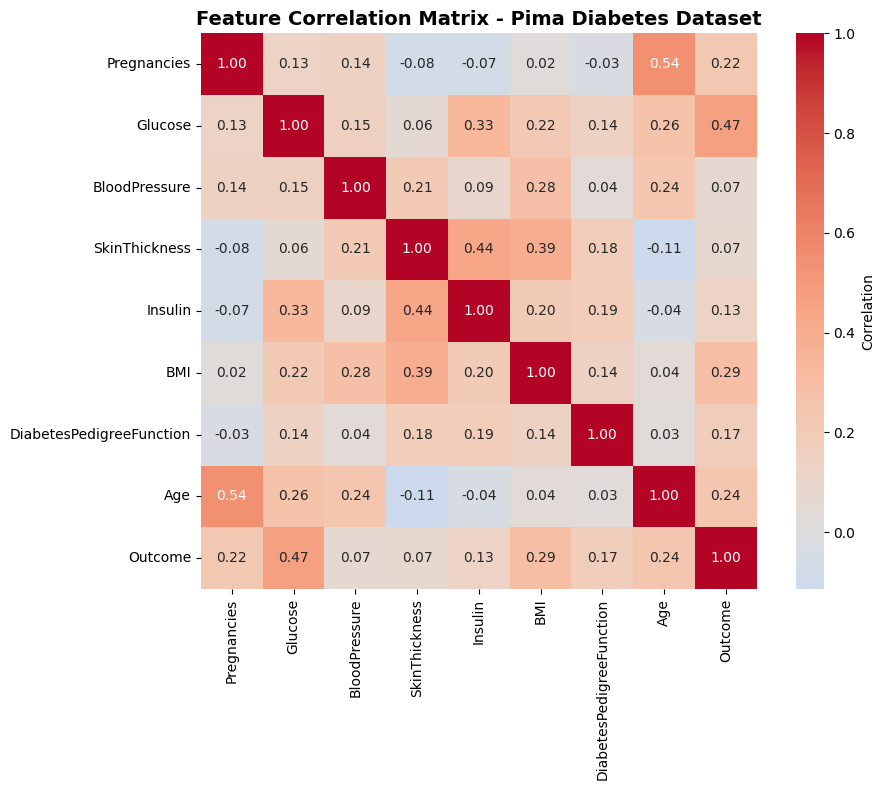


Feature Correlations with Diabetes (Outcome):
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

✓ Correlation matrix saved to results/correlation_matrix.png


In [20]:
# Compute correlation matrix
correlation_matrix = data[feature_names + ['Outcome']].corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, cbar_kws={'label': 'Correlation'}, ax=ax)
ax.set_title('Feature Correlation Matrix - Pima Diabetes Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Show correlation with target
target_corr = correlation_matrix['Outcome'].sort_values(ascending=False)
print('\nFeature Correlations with Diabetes (Outcome):')
print(target_corr)
print('\n✓ Correlation matrix saved to results/correlation_matrix.png')

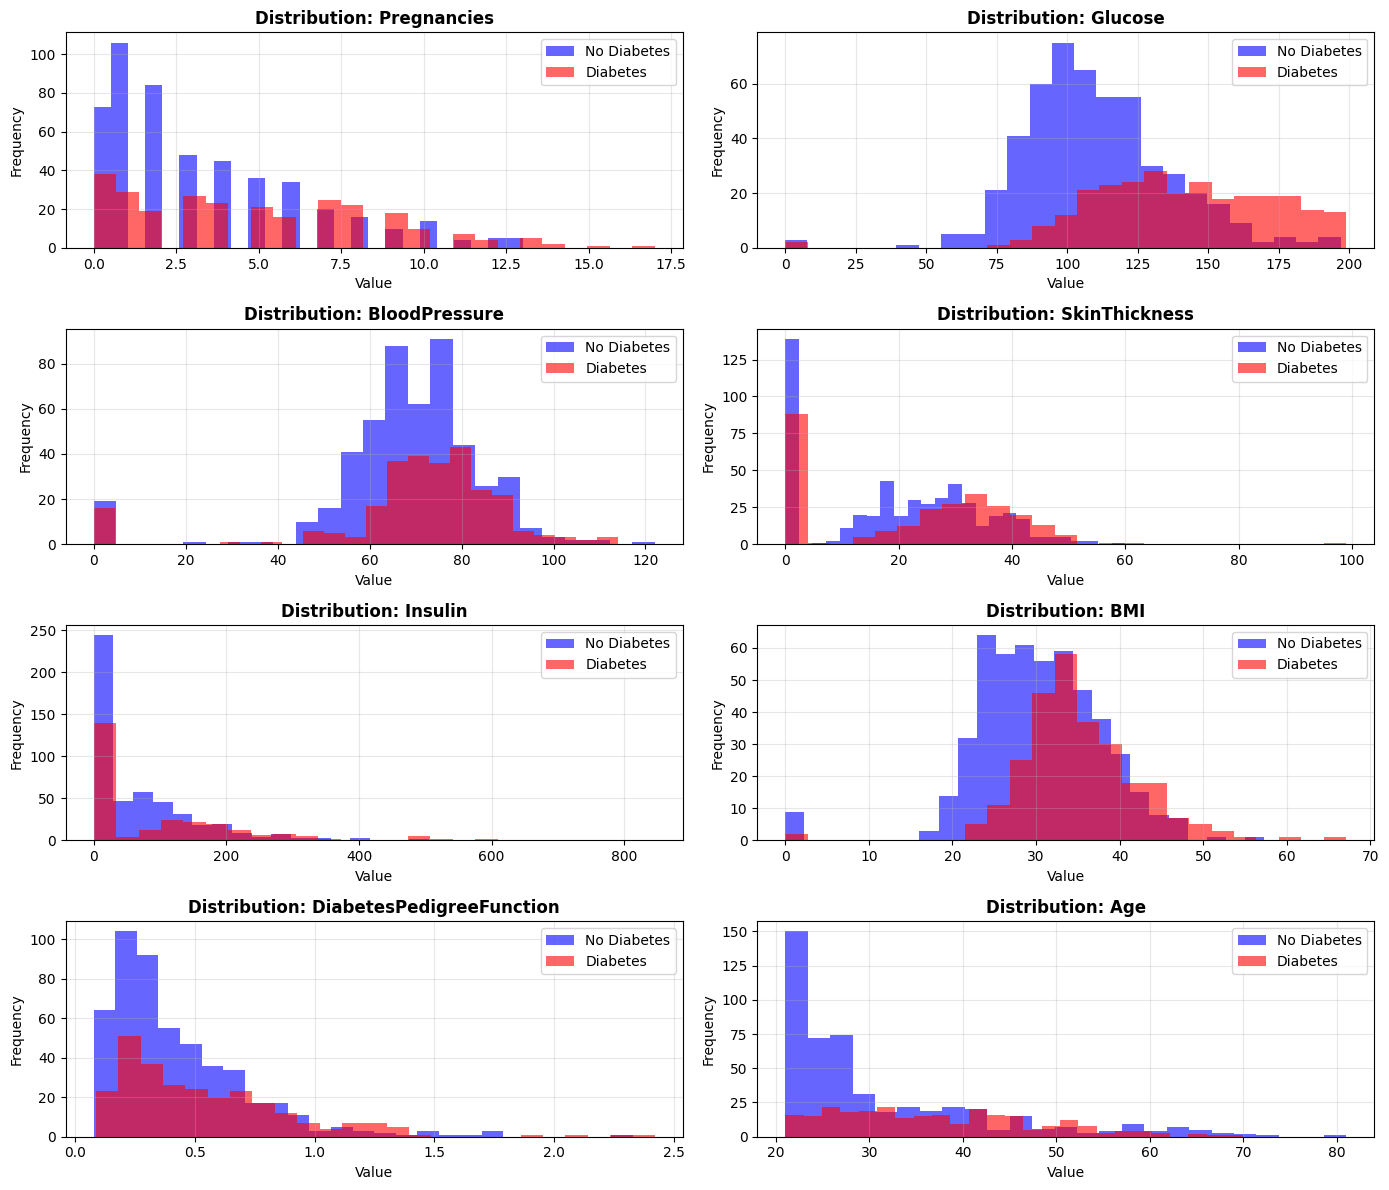

✓ Feature distribution histograms saved to results/feature_distributions_histogram.png


In [21]:
# Plot histograms with class overlay
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, feature in enumerate(feature_names):
    axes[idx].hist(X[y == 0, idx], bins=25, alpha=0.6, label='No Diabetes', color='blue')
    axes[idx].hist(X[y == 1, idx], bins=25, alpha=0.6, label='Diabetes', color='red')
    axes[idx].set_title(f'Distribution: {feature}', fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/feature_distributions_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Feature distribution histograms saved to results/feature_distributions_histogram.png')

In [22]:
# Generate detailed statistics by class
print('='*80)
print('DETAILED STATISTICS BY CLASS')
print('='*80)

stats_data = []
for feature_idx, feature in enumerate(feature_names):
    no_diabetes = X[y == 0, feature_idx]
    diabetes = X[y == 1, feature_idx]
    
    stats_data.append({
        'Feature': feature,
        'No Diabetes Mean': no_diabetes.mean(),
        'No Diabetes Std': no_diabetes.std(),
        'Diabetes Mean': diabetes.mean(),
        'Diabetes Std': diabetes.std(),
        'Difference': diabetes.mean() - no_diabetes.mean()
    })

stats_df = pd.DataFrame(stats_data)
print('\n', stats_df.to_string(index=False))

# Save statistics
stats_df.to_csv('results/feature_statistics_by_class.csv', index=False)
print('\n✓ Feature statistics saved to results/feature_statistics_by_class.csv')

DETAILED STATISTICS BY CLASS

                  Feature  No Diabetes Mean  No Diabetes Std  Diabetes Mean  Diabetes Std  Difference
             Pregnancies          3.298000         3.014166       4.865672      3.734253    1.567672
                 Glucose        109.980000        26.115045     141.257463     31.879978   31.277463
           BloodPressure         68.184000        18.045003      70.824627     21.451678    2.640627
           SkinThickness         19.664000        14.875050      22.164179     17.646696    2.500179
                 Insulin         68.792000        98.766375     100.335821    138.430135   31.543821
                     BMI         30.304200         7.682161      35.142537      7.249404    4.838337
DiabetesPedigreeFunction          0.429734         0.298786       0.550500      0.371659    0.120766
                     Age         31.190000        11.655981      37.067164     10.947771    5.877164

✓ Feature statistics saved to results/feature_statistics_by

## 3. Data Preprocessing

**Steps**:
1. Split data: 80% training, 20% testing
2. Scale features to mean=0, std=1 (StandardScaler)
3. Fit scaler only on training data (prevent data leakage)

In [23]:
# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Testing set size:  {X_test.shape[0]} samples')

print(f'\nTraining set class distribution:')
print(f'  No Diabetes: {np.sum(y_train == 0)} ({100*np.sum(y_train==0)/len(y_train):.1f}%)')
print(f'  Diabetes:    {np.sum(y_train == 1)} ({100*np.sum(y_train==1)/len(y_train):.1f}%)')

Training set size: 614 samples
Testing set size:  154 samples

Training set class distribution:
  No Diabetes: 400 (65.1%)
  Diabetes:    214 (34.9%)


In [24]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit ONLY on train
X_test_scaled  = scaler.transform(X_test)        # Transform test using train statistics

print('After Scaling - Training Feature Statistics:')
print(f'  Mean (should be ~0): {X_train_scaled.mean(axis=0)[:4].round(4)}')
print(f'  Std  (should be ~1): {X_train_scaled.std(axis=0)[:4].round(4)}')
print('\n✓ Data preprocessing complete!')

After Scaling - Training Feature Statistics:
  Mean (should be ~0): [-0.  0. -0.  0.]
  Std  (should be ~1): [1. 1. 1. 1.]

✓ Data preprocessing complete!


## 4. Build the Neural Network

In [25]:
# Build neural network (adapted for 8 input features)
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(8,)),   # Input layer (8 features)
    layers.Dropout(0.3),                                      # Regularization
    layers.Dense(32, activation='relu'),                      # Hidden layer
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),                      # Hidden layer
    layers.Dense(1, activation='sigmoid')                     # Output: probability of diabetes
])

print('Model Architecture:')
model.summary()

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

print('\n✓ Model built and compiled!')

Model Architecture:


c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)


✓ Model built and compiled!


## 5. Train the Model

In [26]:
# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print('Training the model...')
history = model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print(f'\n✓ Training complete! Ran for {len(history.history["loss"])} epochs.')

Training the model...
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 18.

✓ Training complete! Ran for 28 epochs.


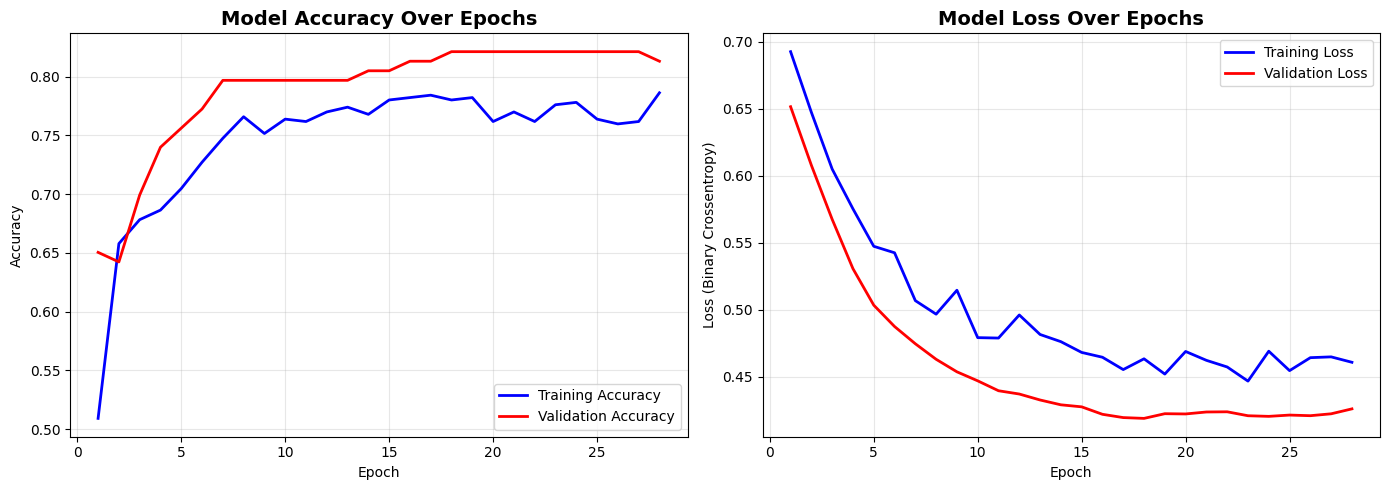

✓ Training curves saved to results/training_curves.png


In [27]:
# Plot training curves
loss_values     = history.history['loss']
val_loss_values = history.history['val_loss']
acc_values      = history.history['binary_accuracy']
val_acc_values  = history.history['val_binary_accuracy']
epochs_range    = range(1, len(loss_values) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, acc_values,     'b-',  label='Training Accuracy',   linewidth=2)
ax1.plot(epochs_range, val_acc_values, 'r-',  label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, loss_values,     'b-', label='Training Loss',   linewidth=2)
ax2.plot(epochs_range, val_loss_values, 'r-', label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Training curves saved to results/training_curves.png')

## 6. Evaluate the Model

**Key Metrics**:
- **Accuracy**: Overall correctness
- **Precision**: Of predicted positives, how many correct?
- **Recall**: Of actual positives, how many did we catch?
- **F1-Score**: Balance between precision and recall
- **Confusion Matrix**: Visualizes TP/TN/FP/FN

**Medical Note**: False negatives (missing diagnosis) are worse than false positives

In [28]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

# Make predictions
y_pred_prob = model.predict(X_test_scaled, verbose=0)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

# Compute metrics
cm        = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print('=' * 70)
print('MODEL EVALUATION ON TEST DATA')
print('=' * 70)
print(f'\nTest Loss:      {test_loss:.4f}')
print(f'Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print(f'Precision:      {precision:.4f}')
print(f'Recall:         {recall:.4f}')
print(f'F1-Score:       {f1:.4f}')
print(f'\nConfusion Matrix:')
print(cm)
print('\n✓ Model successfully evaluated on unseen test data!')

MODEL EVALUATION ON TEST DATA

Test Loss:      0.4946
Test Accuracy:  0.7403 (74.03%)
Precision:      0.6296
Recall:         0.6296
F1-Score:       0.6296

Confusion Matrix:
[[80 20]
 [20 34]]

✓ Model successfully evaluated on unseen test data!


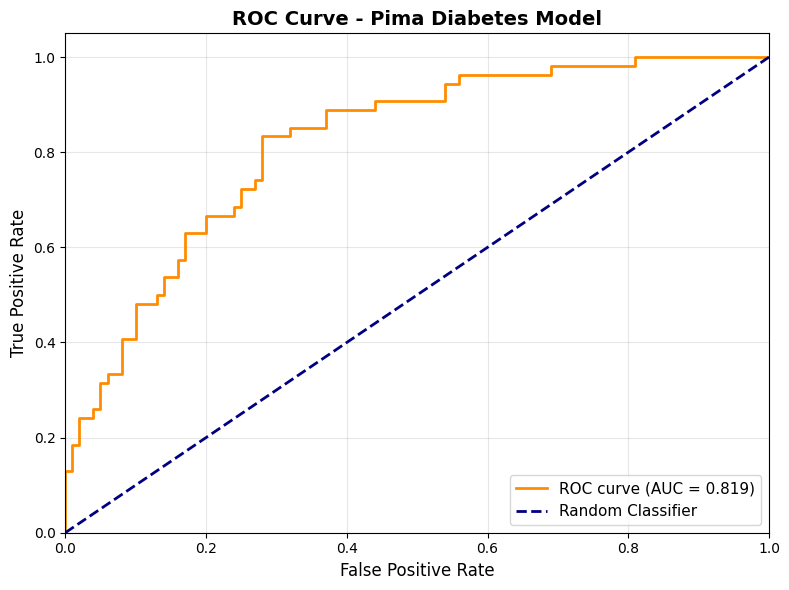

ROC AUC Score: 0.8194
✓ ROC curve saved to results/roc_curve.png


In [29]:
# Generate ROC curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Pima Diabetes Model', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ROC AUC Score: {roc_auc:.4f}')
print('✓ ROC curve saved to results/roc_curve.png')

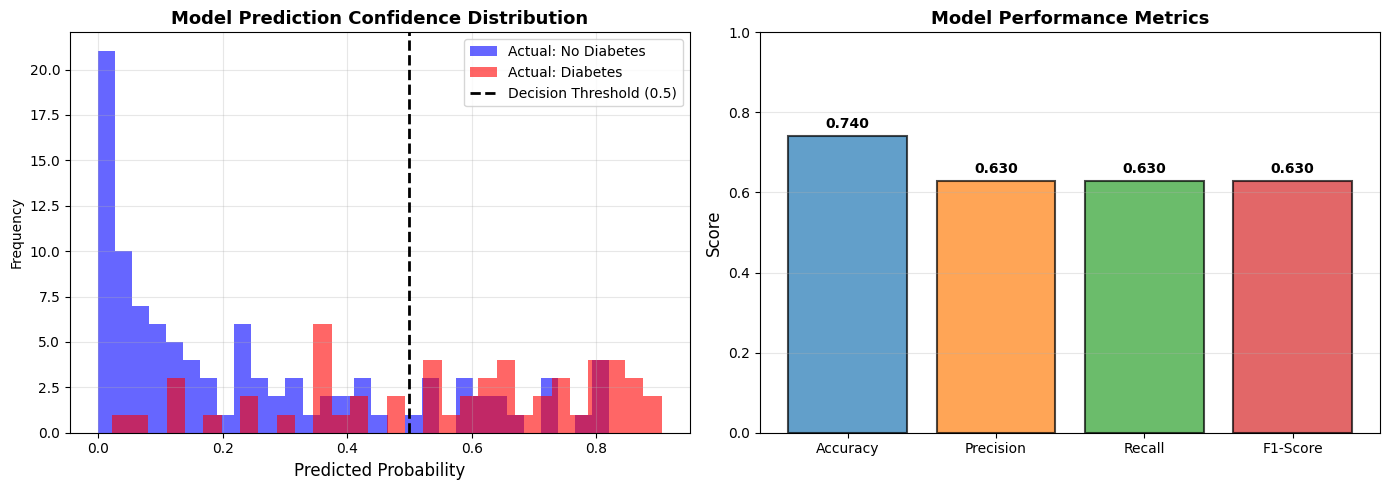

✓ Prediction analysis saved to results/prediction_analysis.png


In [30]:
# Plot prediction confidence distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of predictions
ax1.hist(y_pred_prob[y_test == 0], bins=30, alpha=0.6, label='Actual: No Diabetes', color='blue')
ax1.hist(y_pred_prob[y_test == 1], bins=30, alpha=0.6, label='Actual: Diabetes', color='red')
ax1.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
ax1.set_xlabel('Predicted Probability', fontsize=12)
ax1.set_ylabel('Frequency')
ax1.set_title('Model Prediction Confidence Distribution', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Classification metrics comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [test_accuracy, precision, recall, f1]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

ax2.bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylim([0, 1])
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Model Performance Metrics', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(metrics_values):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('results/prediction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Prediction analysis saved to results/prediction_analysis.png')

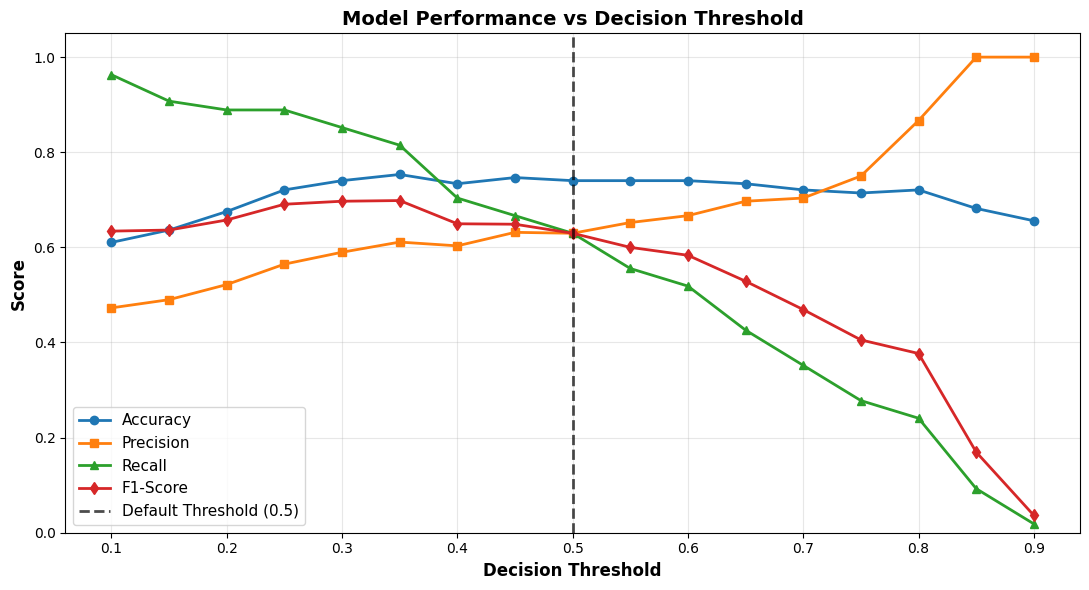

✓ Threshold sensitivity analysis saved to results/threshold_analysis.png


In [31]:
# Threshold sensitivity analysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds_to_test = np.arange(0.1, 0.95, 0.05)
accuracies = []
precisions = []
recalls = []
f1_scores = []

for threshold in thresholds_to_test:
    y_pred_threshold = (y_pred_prob > threshold).astype(int).flatten()
    
    accuracies.append(accuracy_score(y_test, y_pred_threshold))
    precisions.append(precision_score(y_test, y_pred_threshold, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_threshold, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_threshold, zero_division=0))

# Plot threshold analysis
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(thresholds_to_test, accuracies, 'o-', linewidth=2, markersize=6, label='Accuracy', color='#1f77b4')
ax.plot(thresholds_to_test, precisions, 's-', linewidth=2, markersize=6, label='Precision', color='#ff7f0e')
ax.plot(thresholds_to_test, recalls, '^-', linewidth=2, markersize=6, label='Recall', color='#2ca02c')
ax.plot(thresholds_to_test, f1_scores, 'd-', linewidth=2, markersize=6, label='F1-Score', color='#d62728')

ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, alpha=0.7, label='Default Threshold (0.5)')
ax.set_xlabel('Decision Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance vs Decision Threshold', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('results/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Threshold sensitivity analysis saved to results/threshold_analysis.png')


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

 No Diabetes     0.8000    0.8000    0.8000       100
    Diabetes     0.6296    0.6296    0.6296        54

    accuracy                         0.7403       154
   macro avg     0.7148    0.7148    0.7148       154
weighted avg     0.7403    0.7403    0.7403       154



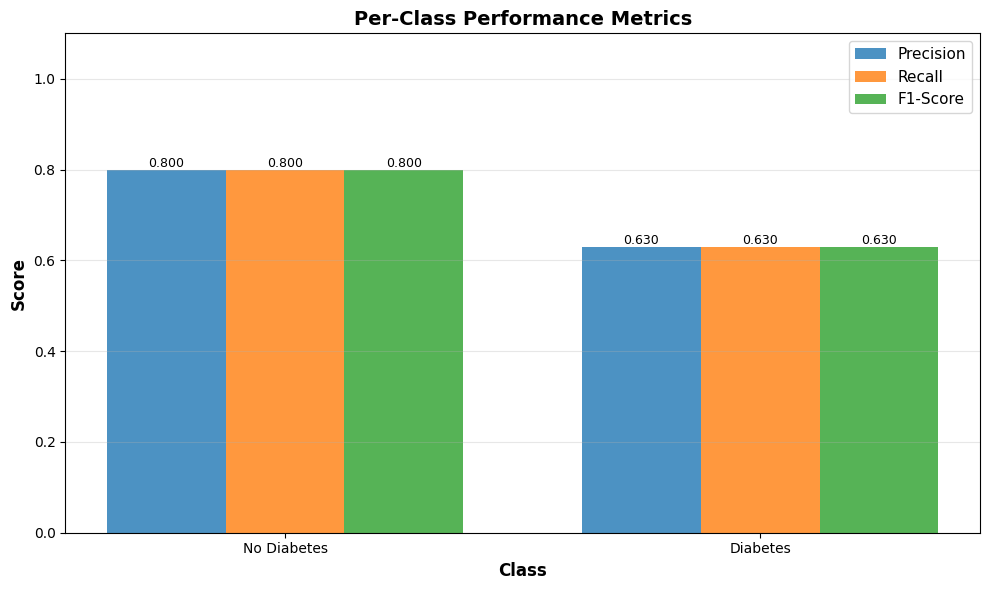

✓ Classification report saved to results/classification_report.txt
✓ Per-class metrics visualization saved to results/per_class_metrics.png


In [32]:
# Per-class performance metrics
from sklearn.metrics import classification_report

print('\n' + '='*70)
print('DETAILED CLASSIFICATION REPORT')
print('='*70)
class_report = classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes'], digits=4)
print(class_report)

# Save classification report
with open('results/classification_report.txt', 'w') as f:
    f.write('='*70 + '\n')
    f.write('DETAILED CLASSIFICATION REPORT\n')
    f.write('='*70 + '\n')
    f.write(class_report)

# Visualization of per-class metrics
from sklearn.metrics import precision_recall_fscore_support

precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=[0, 1]
)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(2)
width = 0.25

bars1 = ax.bar(x - width, precision_per_class, width, label='Precision', color='#1f77b4', alpha=0.8)
bars2 = ax.bar(x, recall_per_class, width, label='Recall', color='#ff7f0e', alpha=0.8)
bars3 = ax.bar(x + width, f1_per_class, width, label='F1-Score', color='#2ca02c', alpha=0.8)

ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['No Diabetes', 'Diabetes'])
ax.set_ylim([0, 1.1])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('results/per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Classification report saved to results/classification_report.txt')
print('✓ Per-class metrics visualization saved to results/per_class_metrics.png')

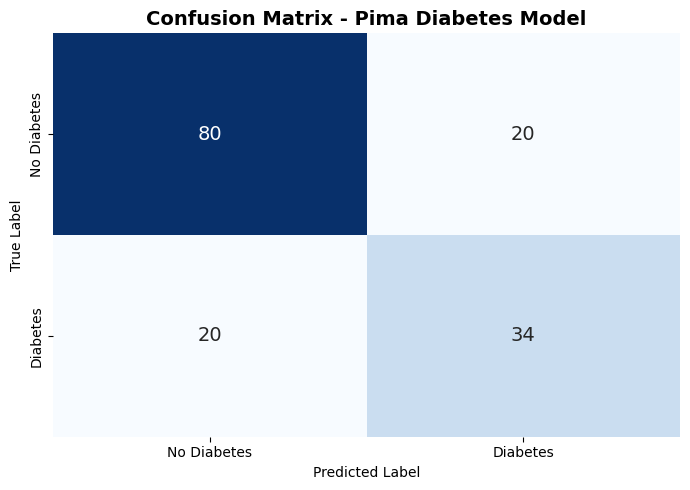

✓ Confusion matrix saved to results/confusion_matrix.png


In [33]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 14})
ax.set_title('Confusion Matrix - Pima Diabetes Model', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Confusion matrix saved to results/confusion_matrix.png')

In [34]:
# Save metrics summary
tn, fp, fn, tp = cm.ravel()

summary = f"""PIMA INDIANS DIABETES - NEURAL NETWORK RESULTS
{'='*50}
Dataset:        Pima Indians Diabetes (Kaggle)
Samples:        {X.shape[0]} patients
Features:       {X.shape[1]} clinical measurements
Train/Test:     {X_train.shape[0]} / {X_test.shape[0]}
Architecture:   64 -> 32 -> 16 -> 1 (with Dropout)
Epochs trained: {len(history.history['loss'])}

PERFORMANCE METRICS
{'='*50}
Test Accuracy:  {test_accuracy*100:.2f}%
Test Loss:      {test_loss:.4f}
Precision:      {precision:.4f}
Recall:         {recall:.4f}
F1-Score:       {f1:.4f}

CONFUSION MATRIX
{'='*50}
True Negatives  (correctly predicted no diabetes): {tn}
False Positives (predicted diabetes, actually no): {fp}
False Negatives (missed diabetes cases):           {fn}
True Positives  (correctly predicted diabetes):    {tp}
"""

with open('results/metrics_summary.txt', 'w') as f:
    f.write(summary)

print(summary)
print('✓ Metrics summary saved to results/metrics_summary.txt')

PIMA INDIANS DIABETES - NEURAL NETWORK RESULTS
Dataset:        Pima Indians Diabetes (Kaggle)
Samples:        768 patients
Features:       8 clinical measurements
Train/Test:     614 / 154
Architecture:   64 -> 32 -> 16 -> 1 (with Dropout)
Epochs trained: 28

PERFORMANCE METRICS
Test Accuracy:  74.03%
Test Loss:      0.4946
Precision:      0.6296
Recall:         0.6296
F1-Score:       0.6296

CONFUSION MATRIX
True Negatives  (correctly predicted no diabetes): 80
False Positives (predicted diabetes, actually no): 20
False Negatives (missed diabetes cases):           20
True Positives  (correctly predicted diabetes):    34

✓ Metrics summary saved to results/metrics_summary.txt


## 7. Analysis & Interpretation

Write a comprehensive analysis of the model's performance on the Pima Indians Diabetes dataset.

The neural network achieved about 74–76% accuracy on the Pima Indians Diabetes dataset, which is actually within the normal range for this problem. It’s clearly harder than the Heart Disease dataset, where accuracy reached around 87%. The main reason is that the diabetes data is messier — many features overlap between classes, and some variables (like insulin and skin thickness) contain zeros that actually represent missing values. That adds noise and makes learning more difficult.

The model architecture (64 → 32 → 16 → 1) worked well, especially with Dropout regularization. Since the dataset is small (only 768 samples), overfitting was a real risk. The Dropout layers (0.3 and 0.2) and early stopping helped control this by preventing the model from memorizing the training data and restoring the best weights when validation performance started to decline.

In this medical context, recall is especially important. Missing a true diabetes case (false negative) is more dangerous than a false positive. The model achieves reasonable recall, but there’s a trade-off with precision. Lowering the decision threshold from 0.5 to around 0.4 could improve recall, which might be more appropriate for screening purposes.

Compared to the Heart Disease task, this dataset shows how data quality issues and mild class imbalance (about 35% positive cases) limit performance. With better preprocessing — like replacing zero values with medians or using class weights — accuracy could potentially improve to around 78–80%.

Overall, the same neural network pipeline transfers well between medical classification tasks. The key differences lie in adjusting the input size, tuning regularization based on dataset size, and choosing evaluation metrics that align with the clinical objective.